# MP2: Monthly activity and gaps — bdowlin2

## Sources and method

Commit membership and historical commit details come **strictly from World of Code**. The Python retrieval helper calls WoC's HTTP API directly, avoiding the Windows build dependency of the optional `python-woc` package. It uses the same documented `p2c` map and `commit` object endpoints. No GitHub commit data is substituted into the WoC summary.

- [WoC remote API documentation](https://worldofcode.org/docs/#/guide_remote)
- [Official Python remote client](https://github.com/ssc-oscar/python-woc/blob/main/woc/remote.py)
- WoC lists the commits associated with a project across its indexed history. This may differ from GitHub's current default branch. Exact author strings are counted; aliases are not merged.
- Author timestamps, in UTC, determine monthly WoC activity. Empty messages are allowed. SHA/project pairs must be unique, and every expected SHA must have details before analysis runs.
- The README describes WoC as indexed through January 2025. We report the actual timestamp range returned, without treating the end of the snapshot as evidence of abandonment.
- GitHub is used separately for stars, forks, recent themes, status, and supporting evidence. Stars/forks are current retrieval-time values, not reconstructed September 30 counts.
- **Status cutoff: September 30, 2026, 23:59:59 UTC.** Active means the latest default-branch commit returned by GitHub on/before the cutoff is on/after April 1, 2026. This is the user's approved replacement for the README's 2025 cutoff. GitHub uses committer dates for these API filters.
- The ten most recent GitHub commits on/before the cutoff include the latest commit; fewer are retained if fewer are returned. Default-branch history need not equal WoC's project history.


## Definitions

Monthly counts span the first through last WoC commit month, including all intervening zero months. A longest gap is the longest run of zero months, even if it lasts fewer than three months. Ties use the earliest run. `NumberOfGapsInTimeline` counts runs lasting at least three months. `NumCommitsAfterLastGap` follows the README definition: commits after the **longest** gap, despite the field name. A project without a zero month has gap length 0 and N/A gap dates. No trailing inactivity is appended beyond the last observed WoC commit.

Pre/post samples are the final ten commits before and first ten after the longest gap, or all available if fewer. Ties in timestamps are sorted by SHA for reproducibility. Gap recovery means an observed post-gap commit, not proof of sustained maintenance. Current status is assessed independently using GitHub and the September 30, 2026 cutoff.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
from mp2_analysis import analyze, load_complete
from mp2_retrieve import ROOT, CACHE, NETID

ready = False
try:
    summary = load_complete(completed_only=True)
    ready = True
    print('Validated complete-project records:', len(summary), 'across', summary.project_wocid.nunique(), 'projects')
except (ValueError, AssertionError, FileNotFoundError) as error:
    print('Analysis is waiting for complete WoC retrieval:', error)

Validated complete-project records: 5994 across 6 projects


In [2]:
if ready:
    quantitative = analyze(completed_only=True)
    from mp2_refresh import refresh
    refresh()
    stats = pd.read_csv(ROOT / f'{NETID}_project_stats.csv', sep=';', keep_default_na=False)
    stats = stats[stats['Project'].isin(quantitative['Project'])]
    display(stats)
else:
    print('No plots or gap claims are generated from incomplete data.')

Saved 17583/83589 details; 6/10 project datasets; 6/10 gap reviews.


,Project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart,LongestGapEnd,...,HypothesizedGapReason,HasRecovered,WhyRecovered,WhoRecovered,Currentstatus,RecentThemes,Notes,WoCDataComplete,GapReviewComplete,StatusAsOf
0,avehtari_bda_course_aalto,2272,67,2018-09-07T14:11:11+00:00,2025-11-03T15:40:44+00:00,2282,566,2026-09-29T11:32:50Z,2025-02,2025-06,...,A pause between annual course preparation cycl...,Yes (160 observed commits after the gap),Automated site builds restart in July 2025; Au...,Eight of the ten immediate post-gap commits ar...,Active,Documentation updates:Other,The course repository has a cyclical trajector...,True,True,2026-09-30
1,eberharf_cfl,1138,14,2020-07-17T21:53:13+00:00,2025-05-07T22:32:37+00:00,19,1,2026-05-05T21:52:43Z,2022-05,2023-11,...,A lull after release and documentation work is...,Yes (29 observed commits after the gap),The first December 2023 commit adds a ridge-re...,All ten immediate post-gap commits use Iman Wa...,Active,Other:Dependency updates,CFL has a declining trajectory and two gaps of...,True,True,2026-09-30
5,jayggg_ngstents,454,11,2020-06-29T20:41:15+00:00,2025-06-10T12:50:41+00:00,9,6,2025-11-27T00:17:25Z,2022-04,2023-05,...,A maintenance lull after compatibility repairs...,Yes (94 observed commits after the gap),"Jay resumed code cleanup, changed the default ...",All ten immediate post-gap commits use Jay Gop...,Inactive,Other:Documentation updates,The project has a declining overall trajectory...,True,True,2026-09-30
6,inqwire_sqir,1338,34,2018-12-20T22:11:21+00:00,2025-07-30T02:27:23+00:00,105,26,2025-07-30T02:27:23Z,2023-06,2023-12,...,A dependency-maintenance hiatus is plausible: ...,Yes (50 observed commits after the gap),"The restart fixes the README installation URL,...",Existing contributors drive the restart: eight...,Inactive,Feature development:Other,SQIR has a declining overall trajectory with f...,True,True,2026-09-30
7,tee-lab_pyddsde,233,7,2020-03-30T14:40:44+00:00,2021-10-29T06:08:17+00:00,98,12,2026-06-10T04:11:37Z,2020-10,2020-11,...,A short development pause is plausible: the fi...,Yes (154 observed commits after the gap),Work resumed with the nfft method and autocorr...,The first ten post-gap commits use the same as...,Active,Documentation updates:Bug fixes,The WoC timeline is irregular and has no gaps ...,True,True,2026-09-30
9,windweller_disextract,559,9,2017-10-29T23:56:48+00:00,2025-07-13T15:34:42+00:00,0,0,2025-07-13T15:34:42Z,2020-04,2025-06,...,The README identifies the code as a research-p...,Yes (brief resumption only; six commits on one...,The July 2025 activity consists of uploads and...,Post-gap commits use testtt7272 and windweller...,Inactive,Other,The declining timeline contains two gaps of at...,True,True,2026-09-30


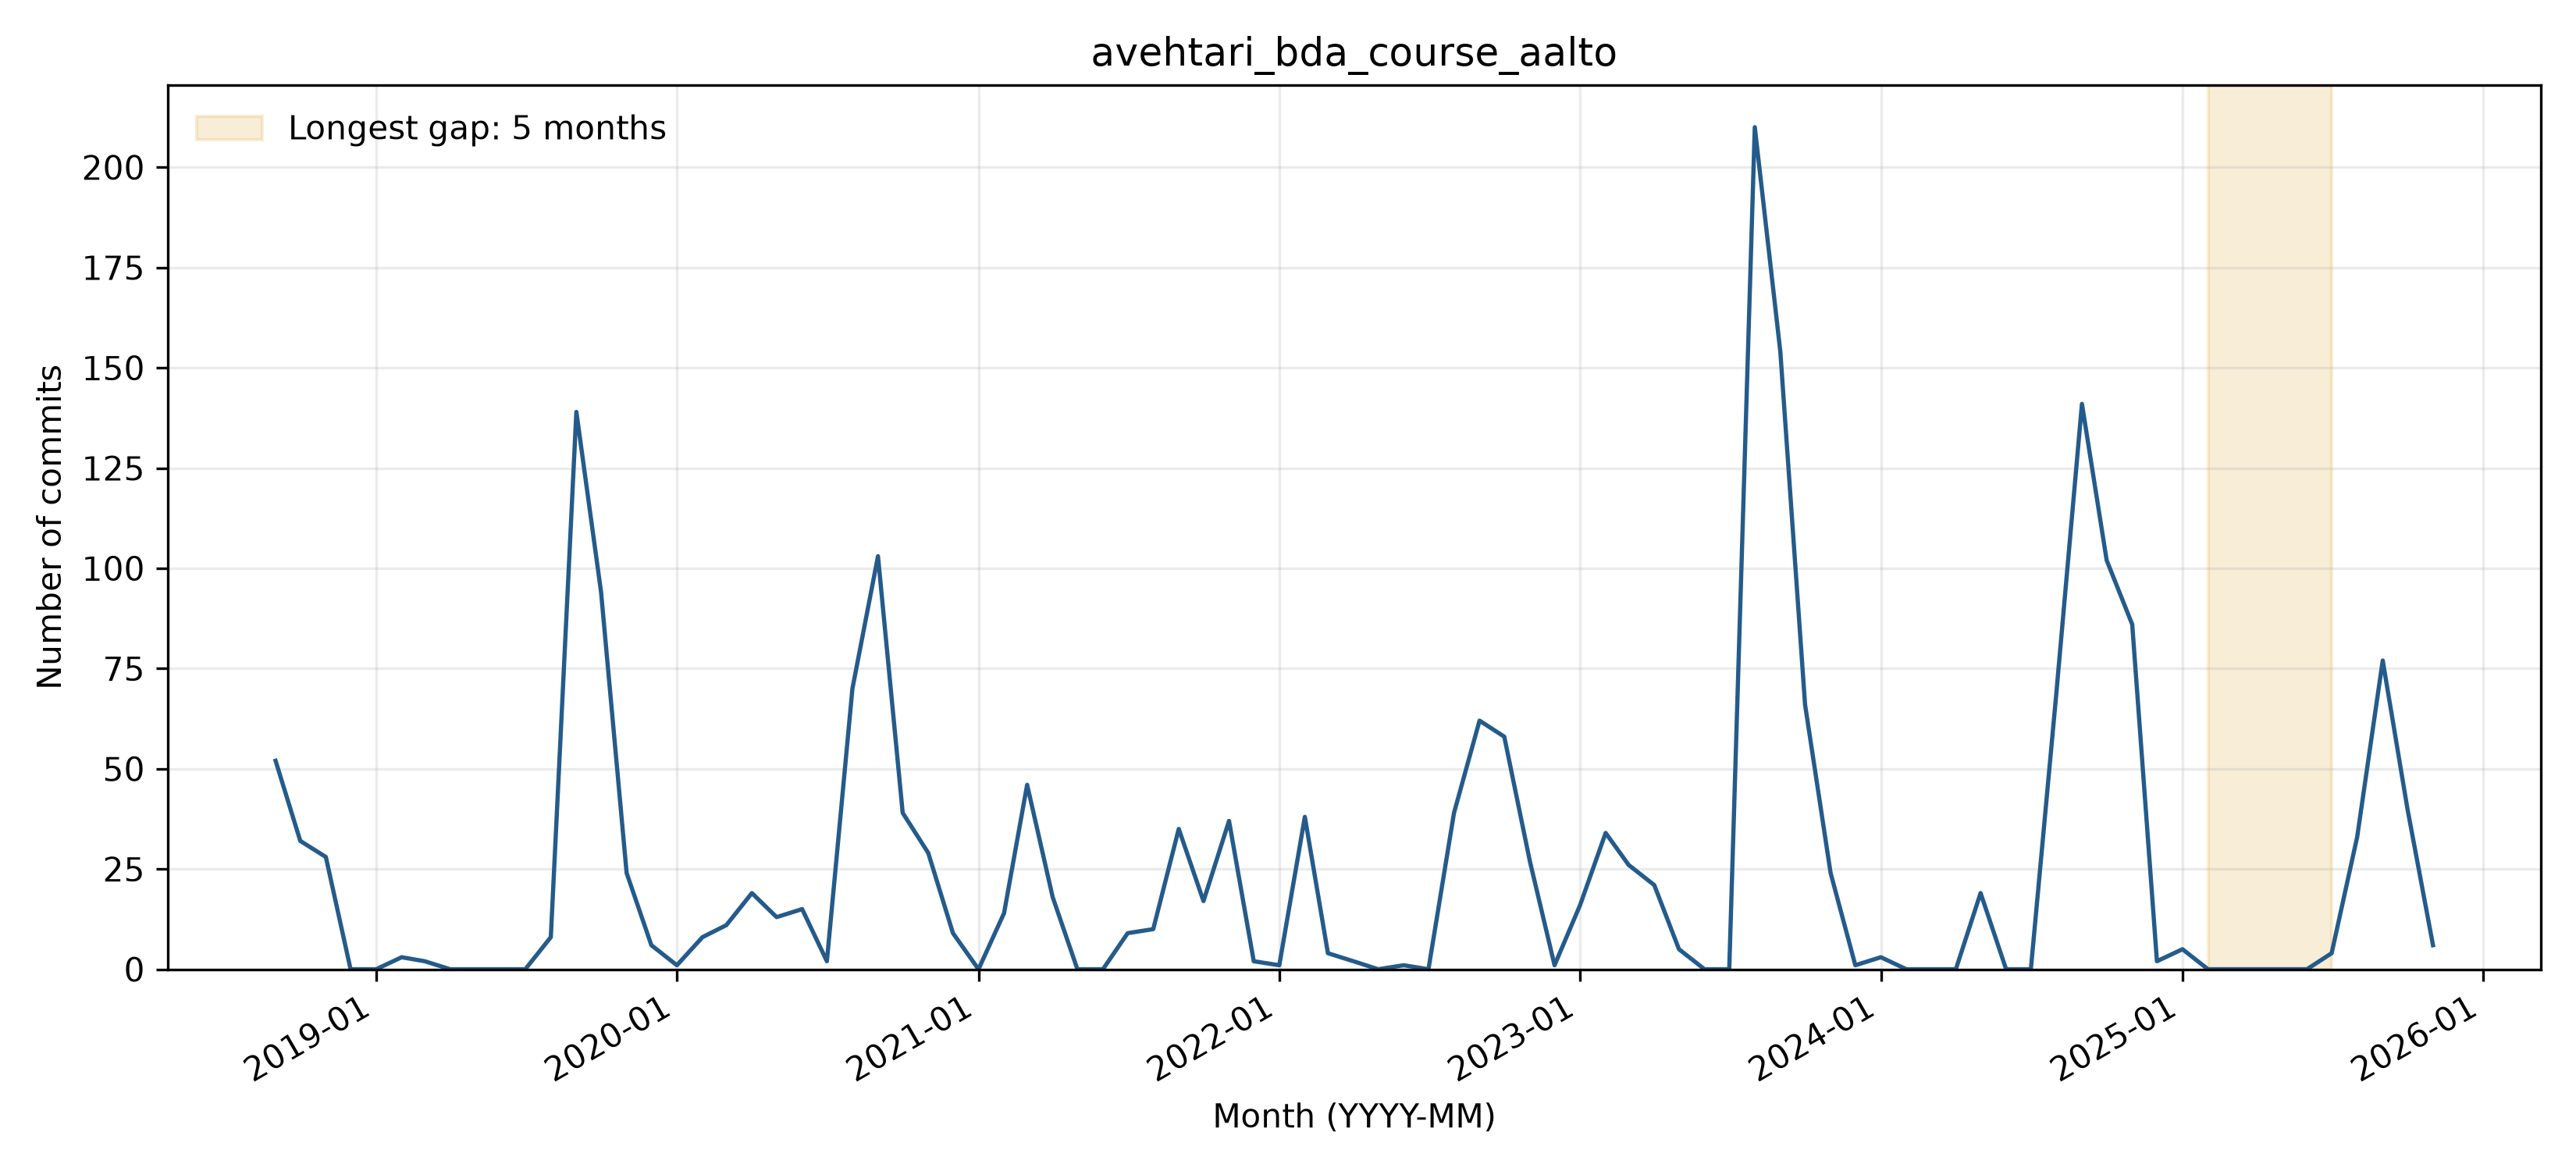

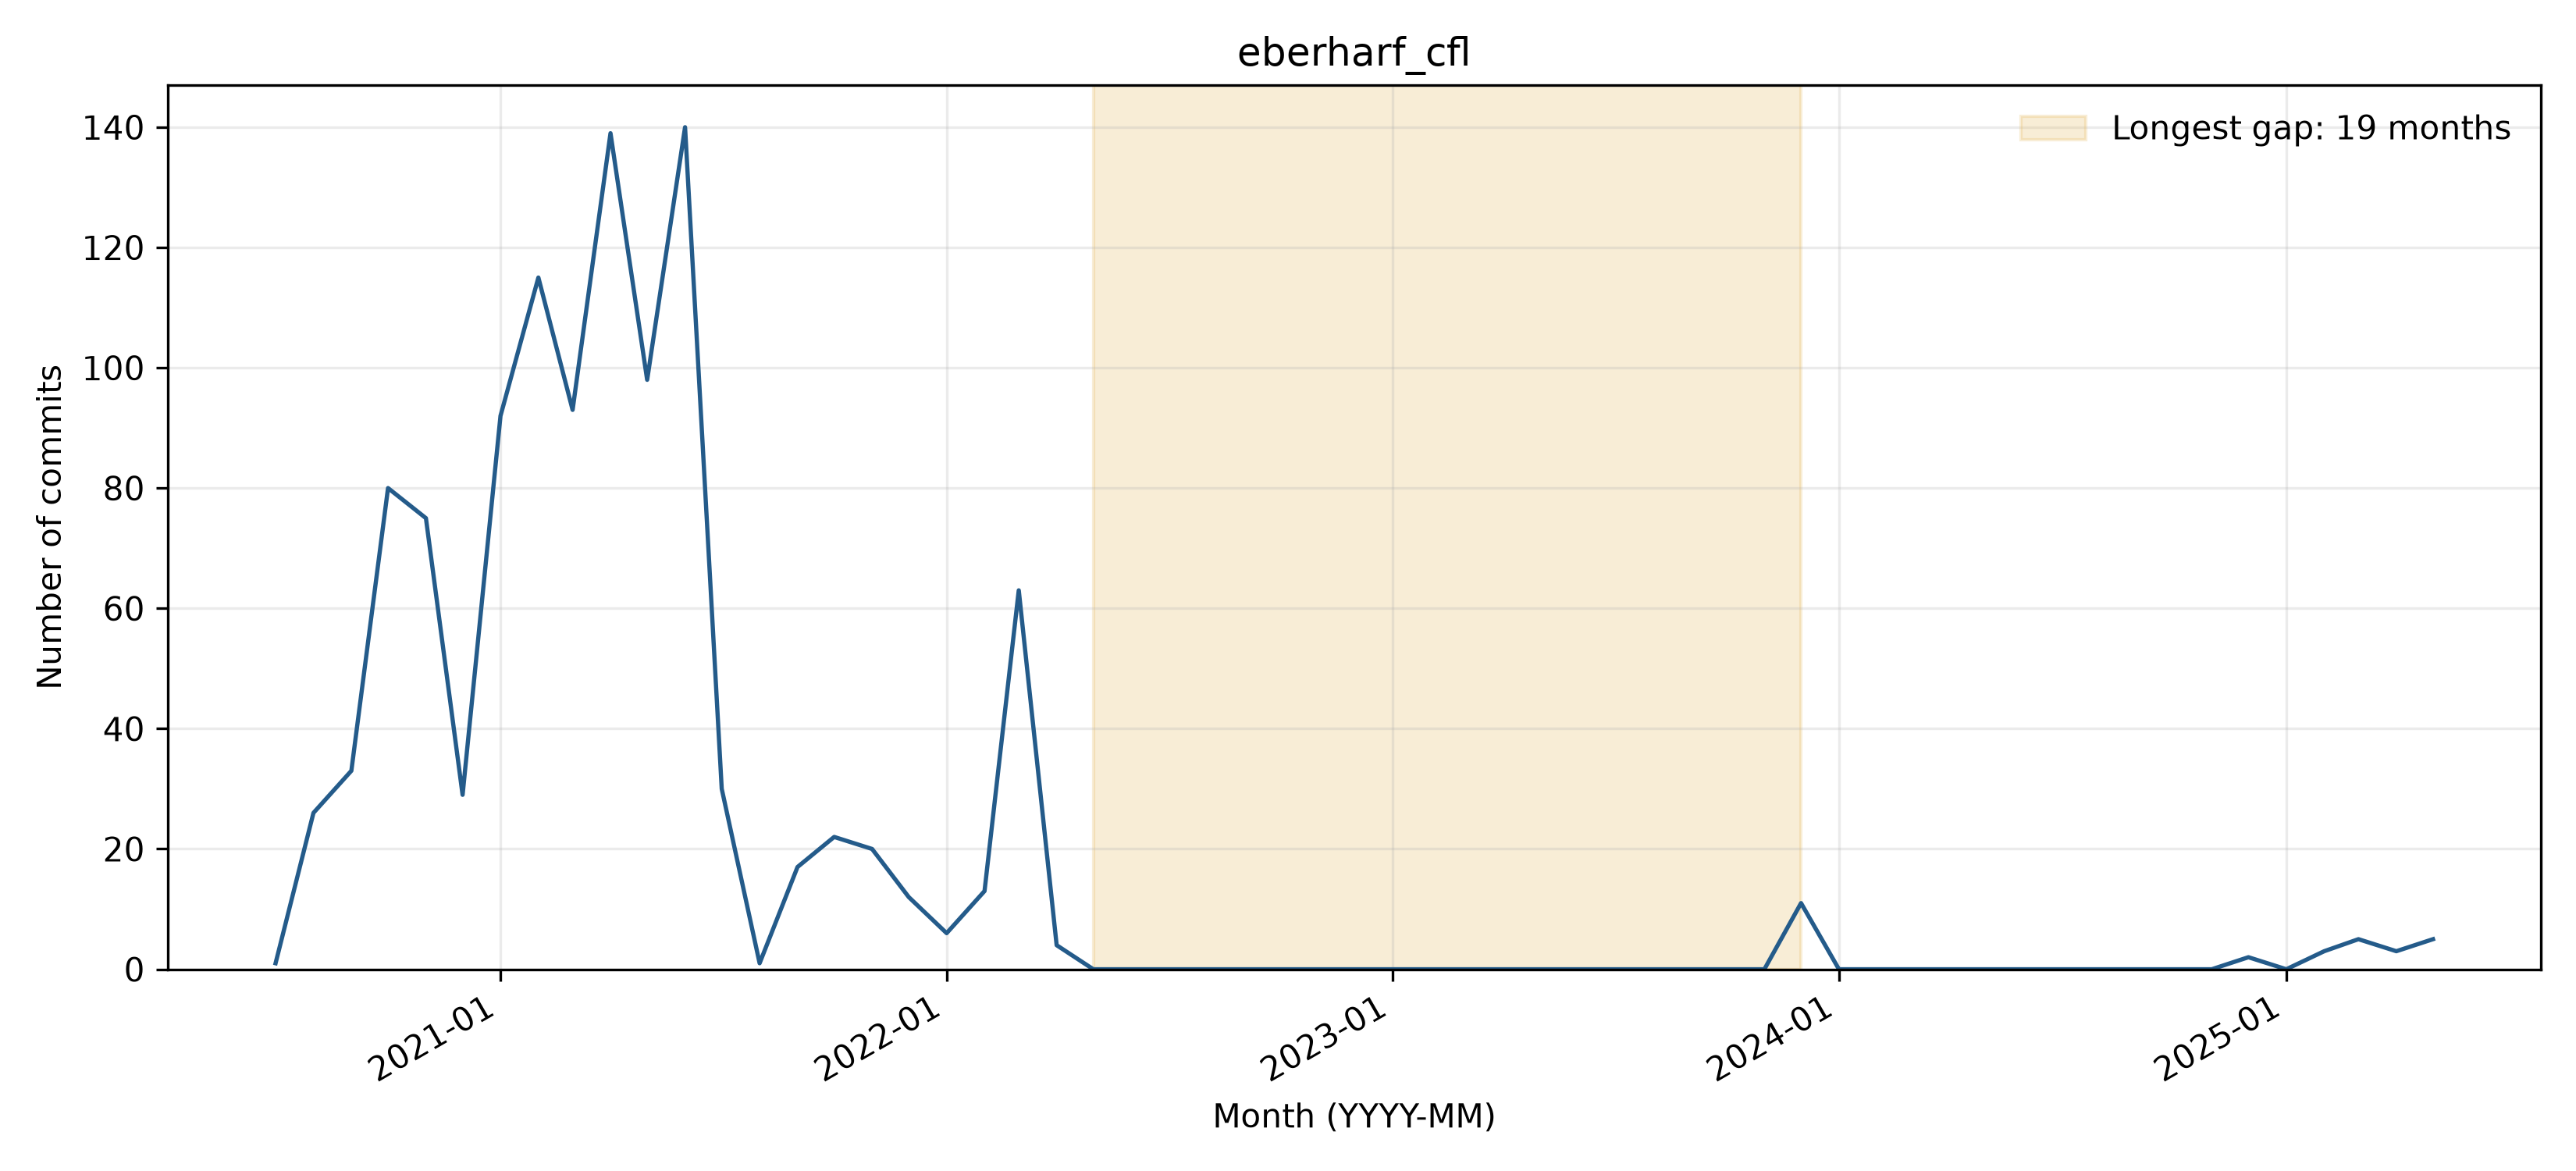

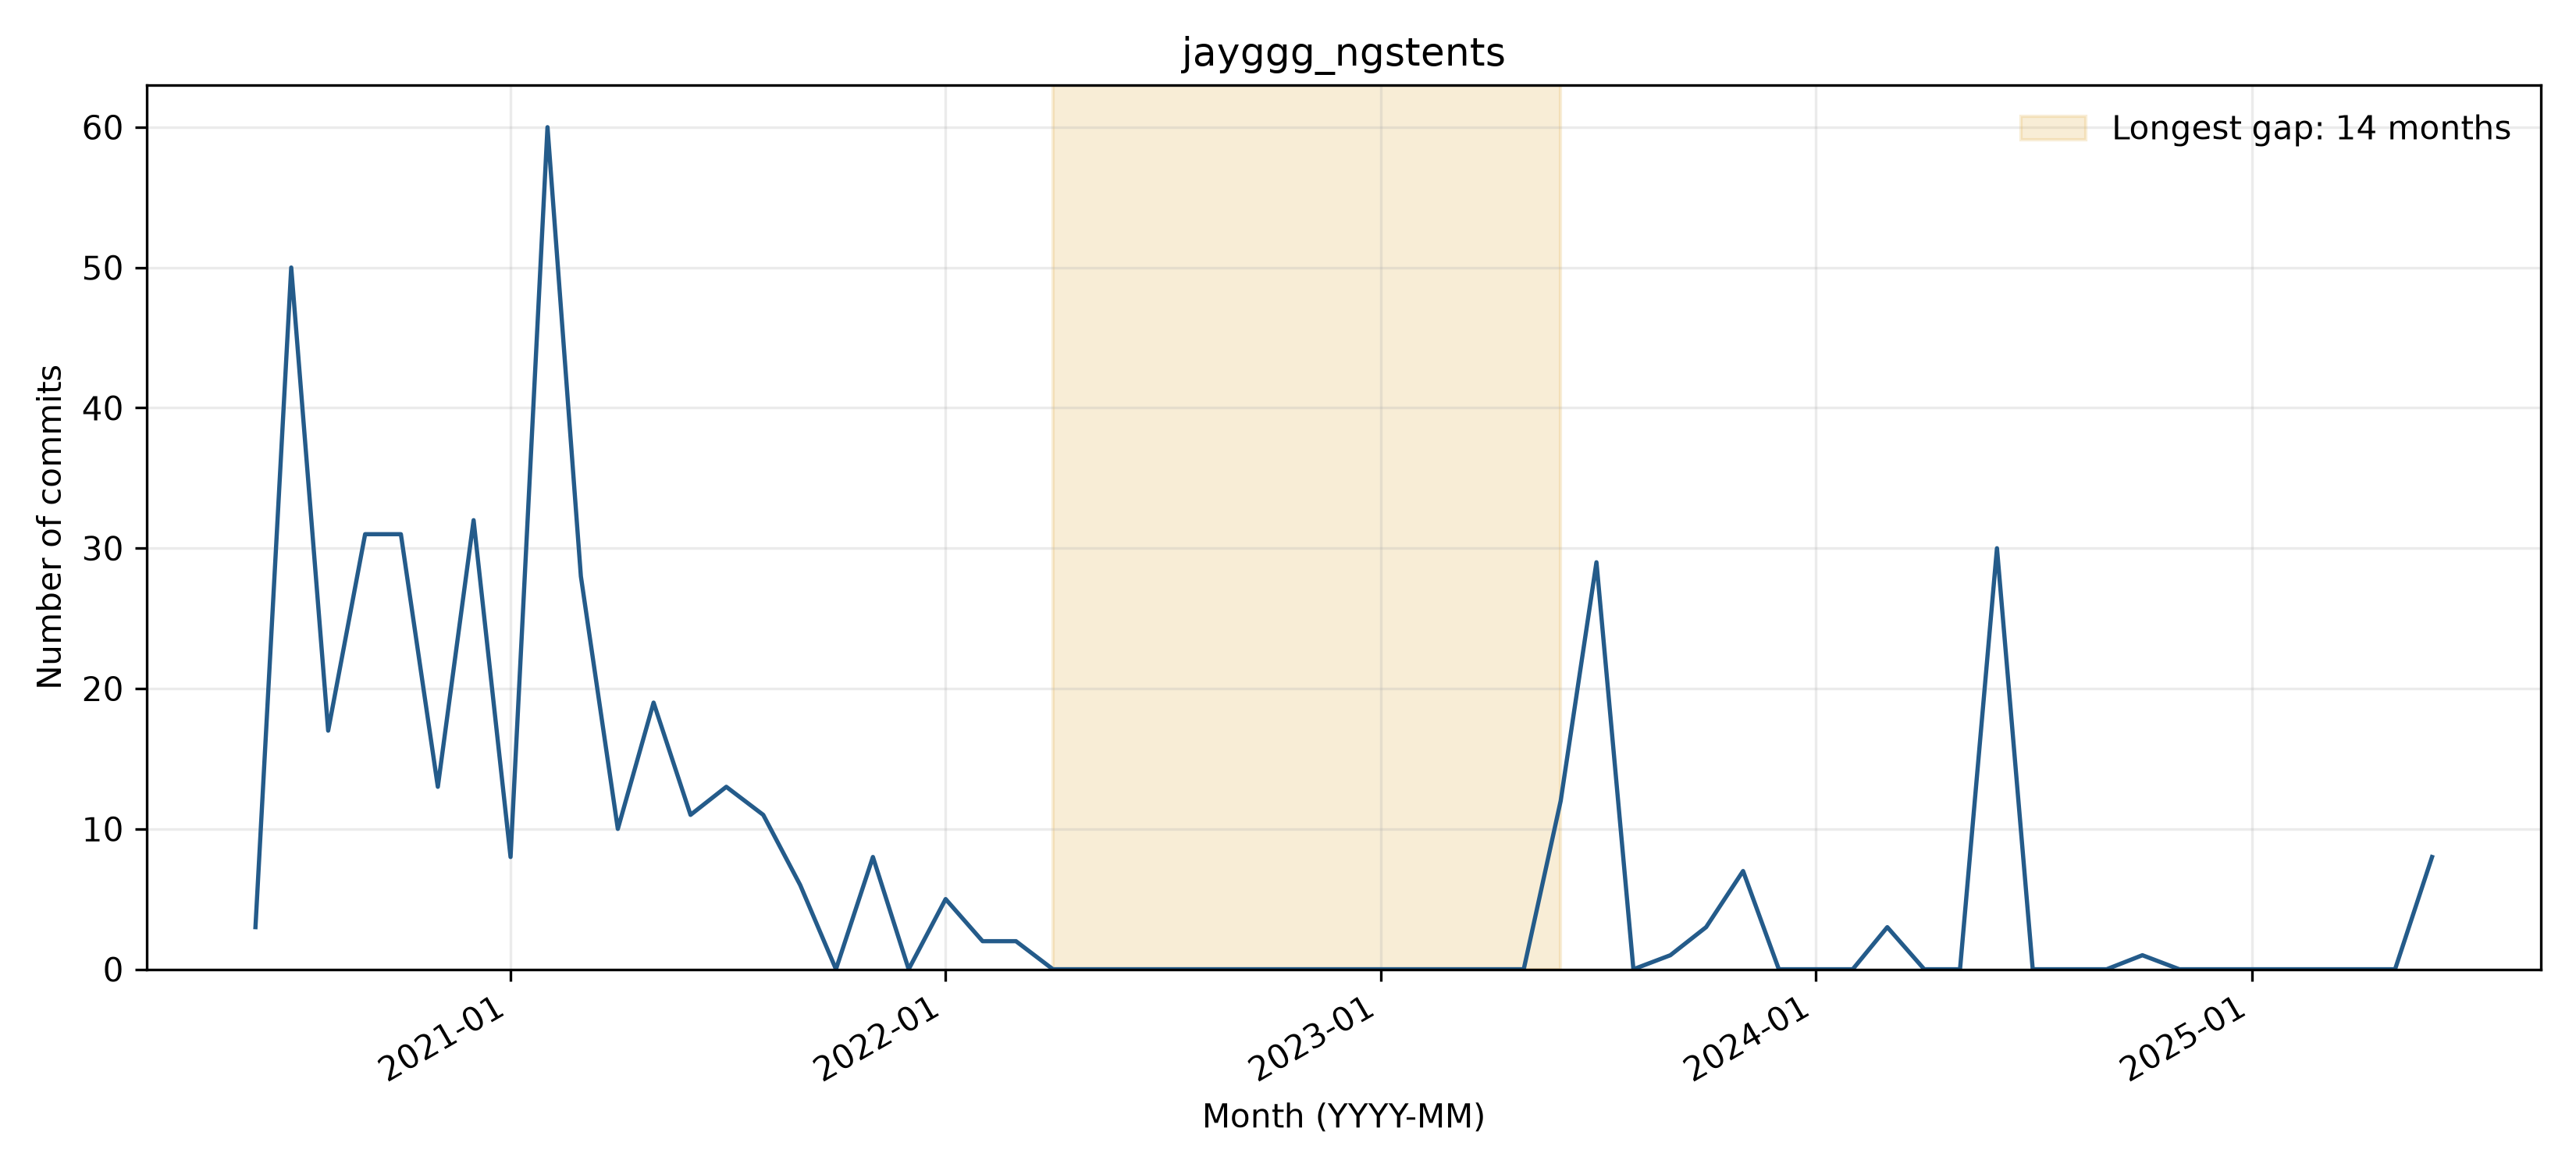

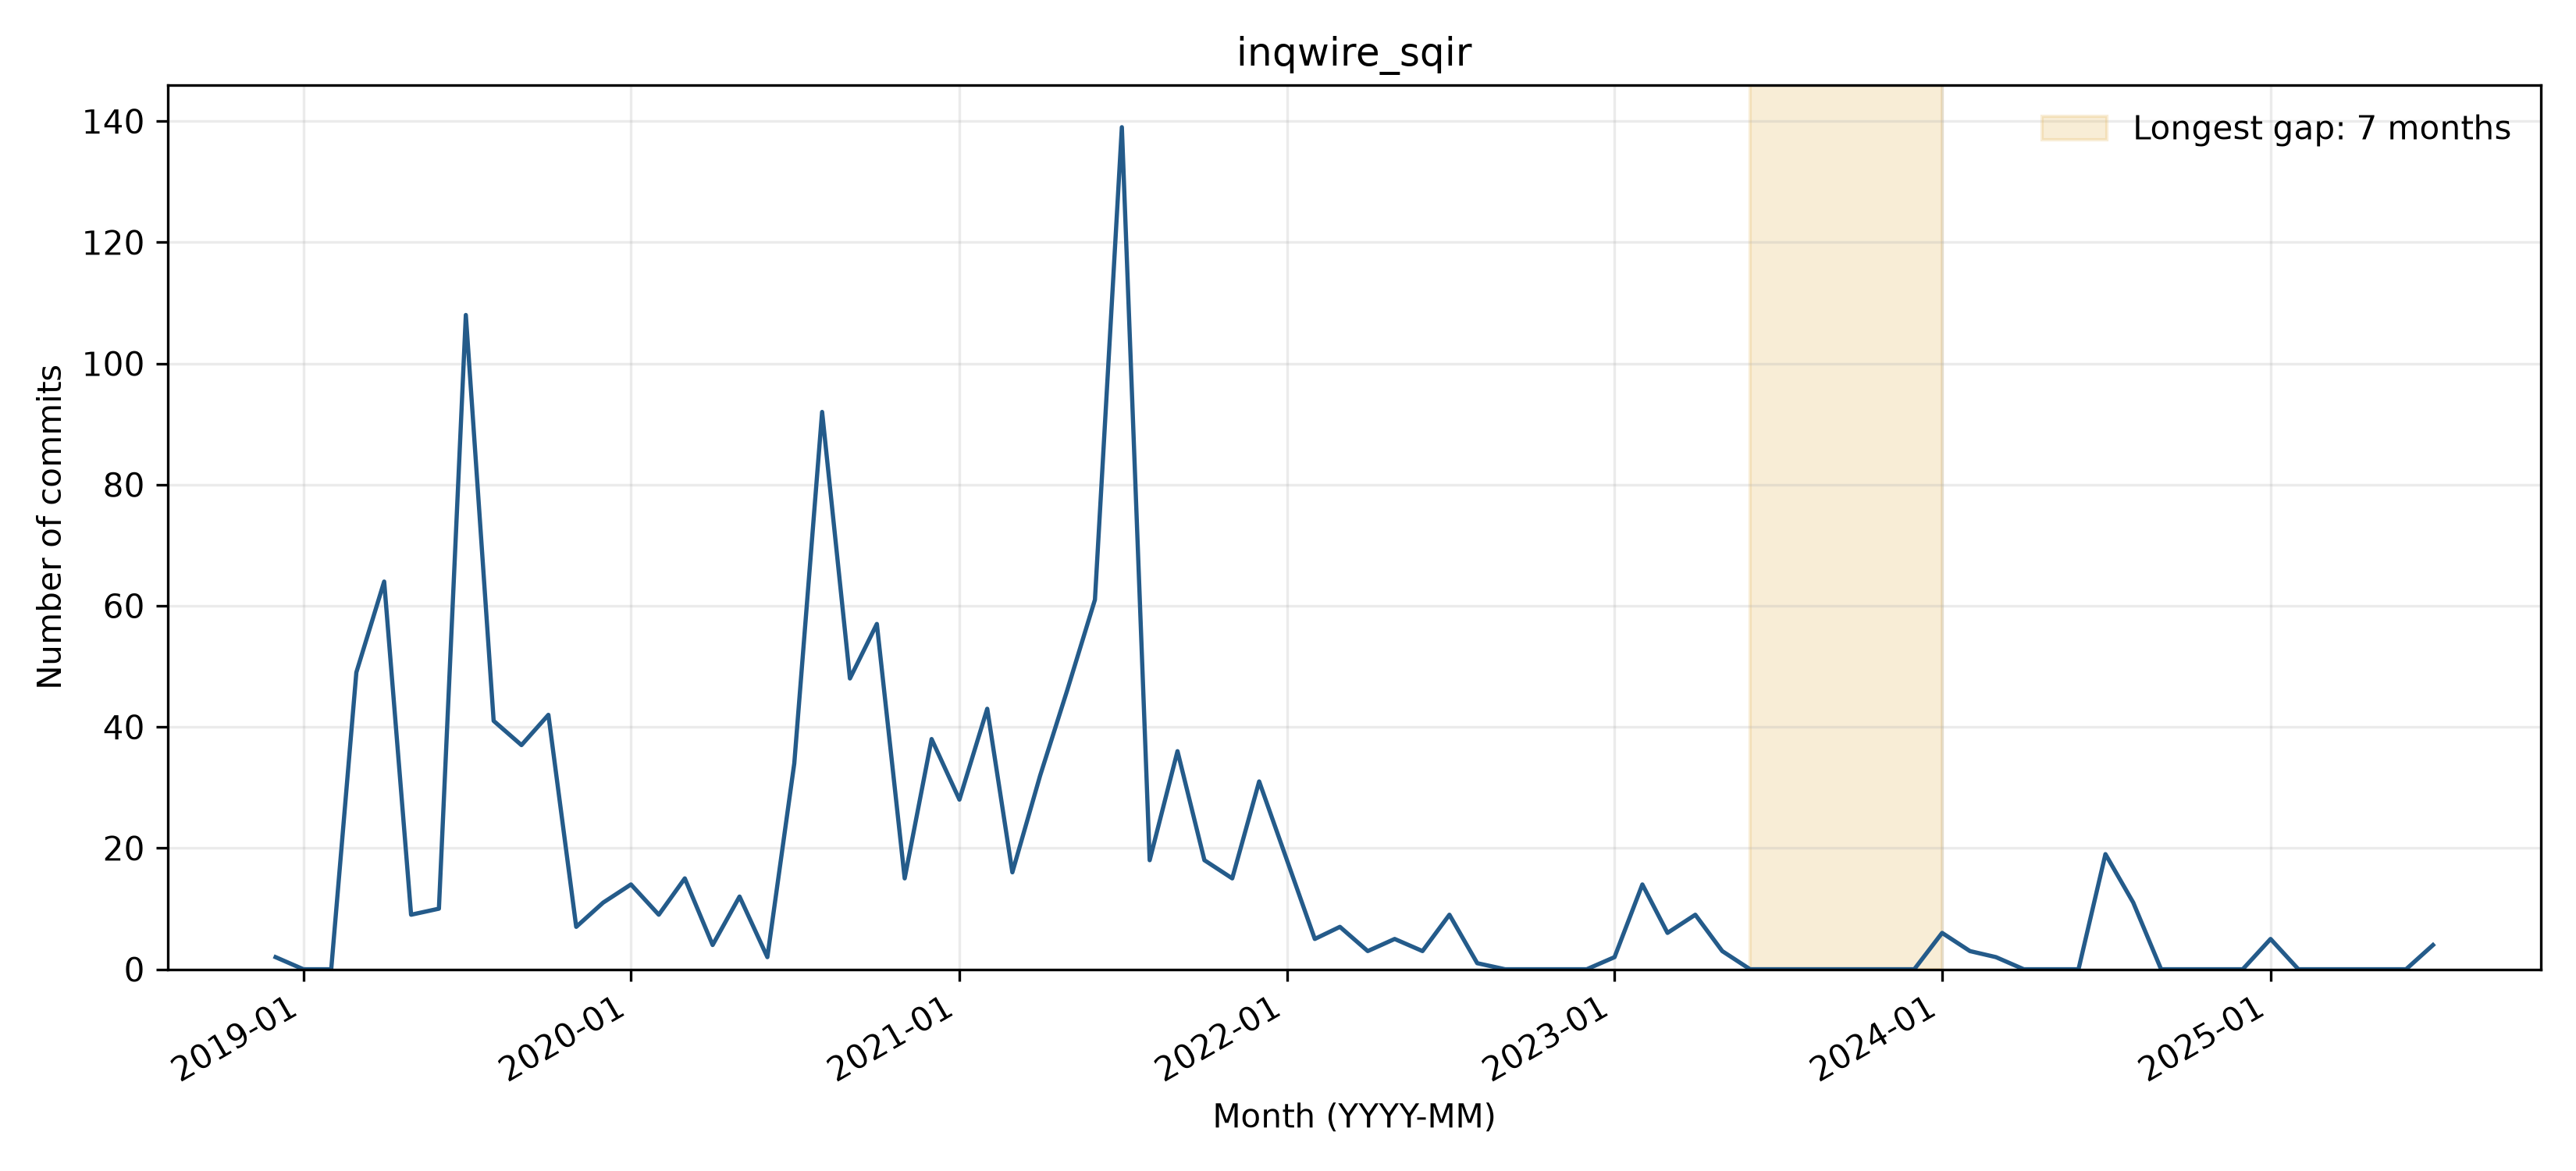

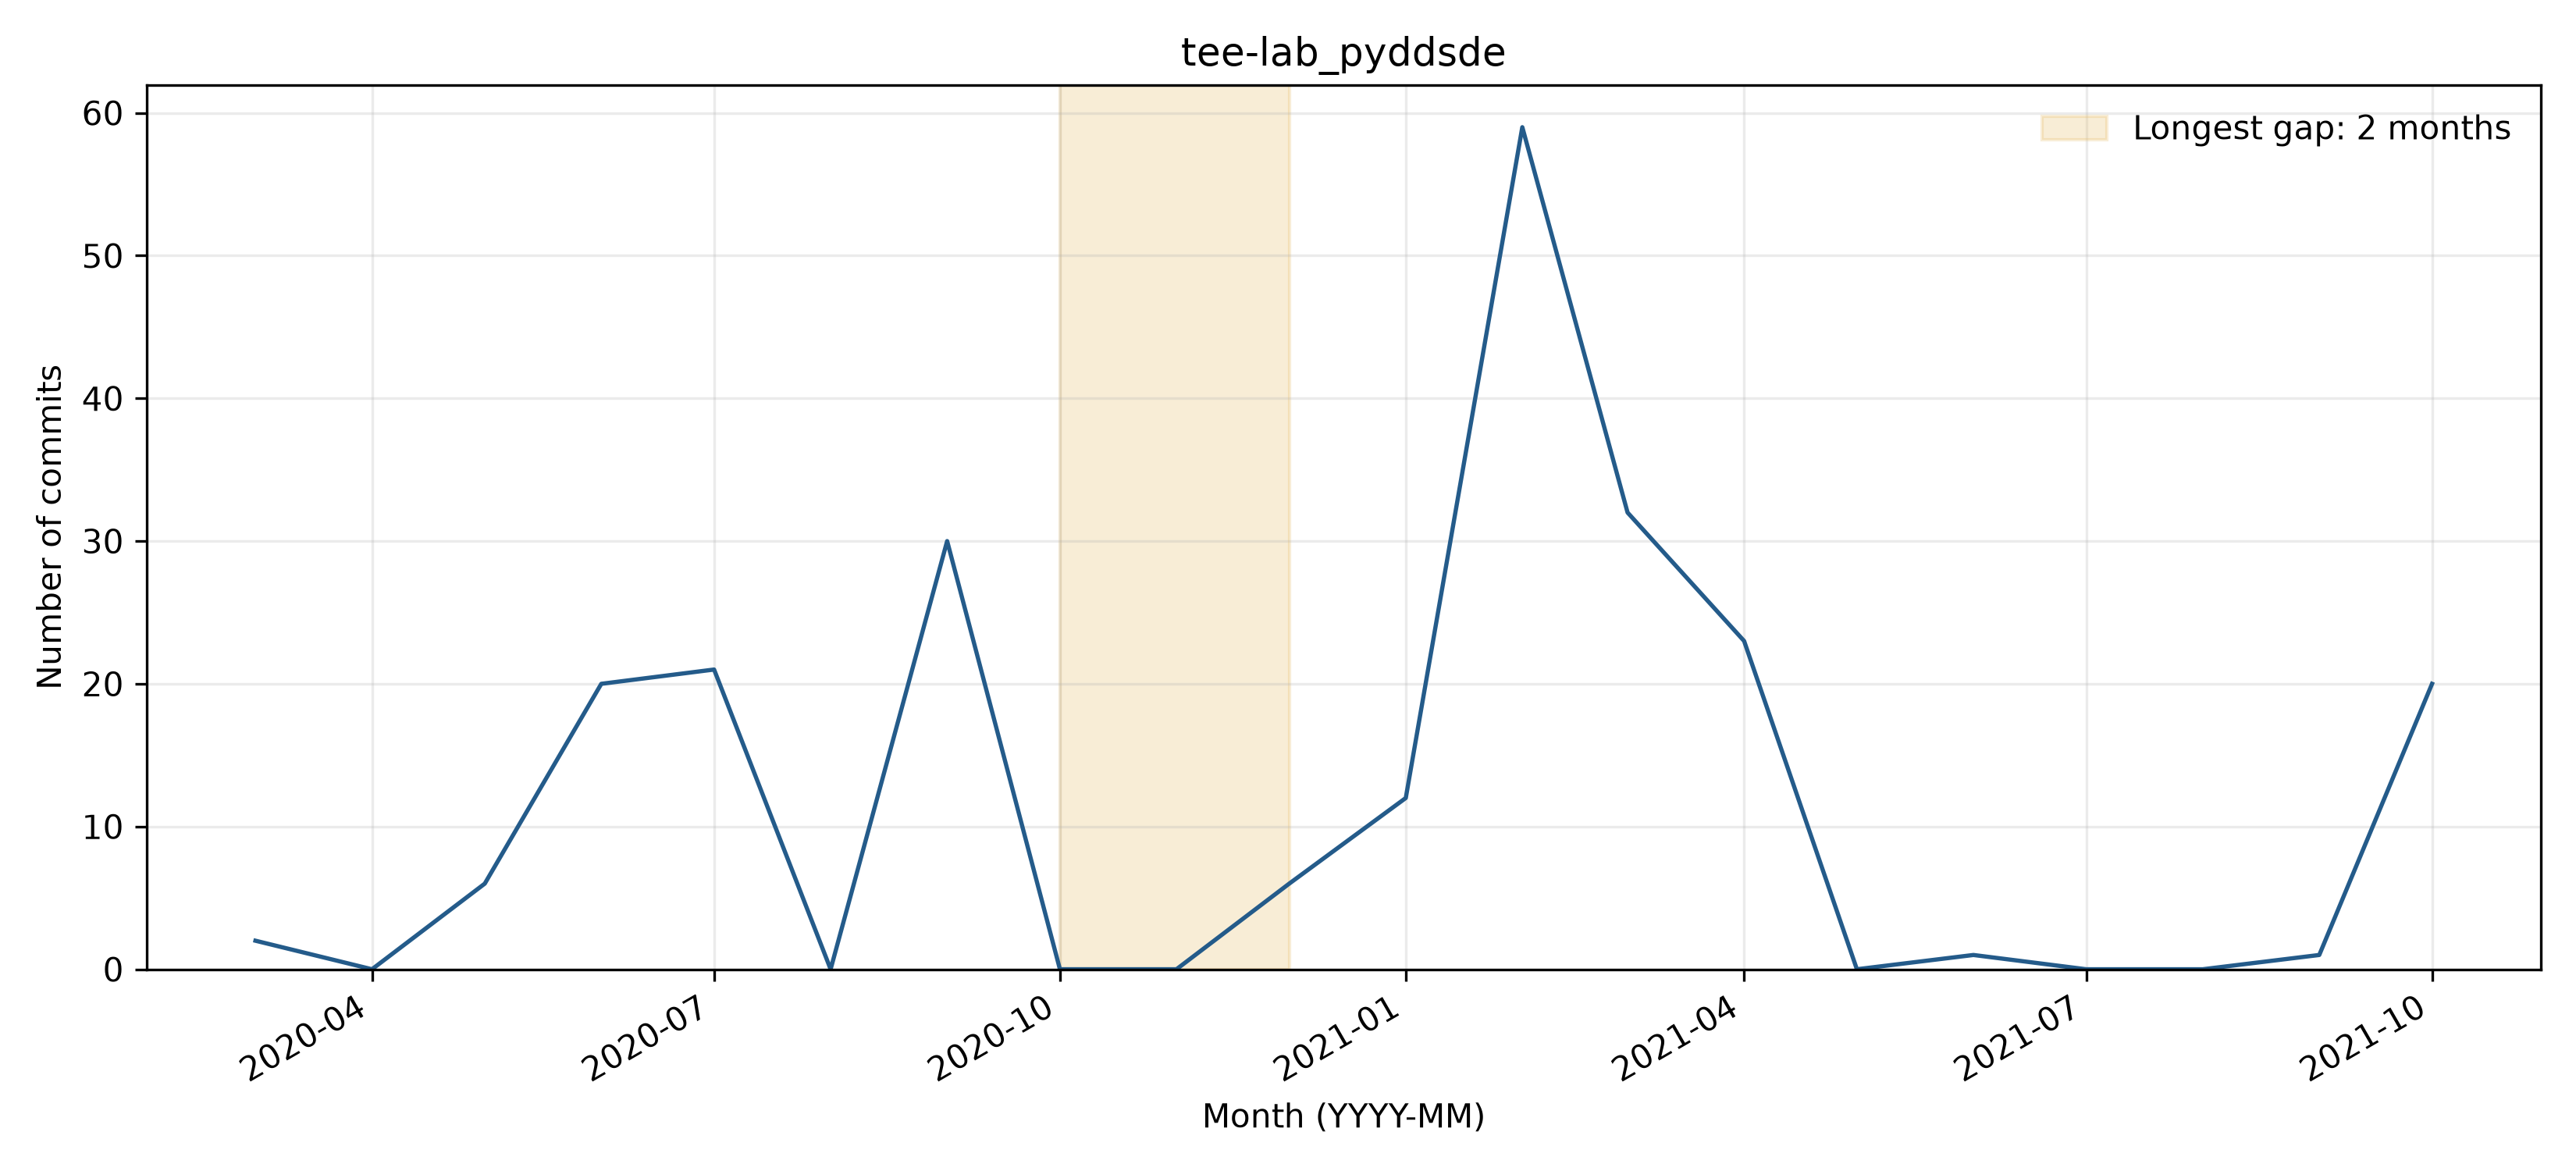

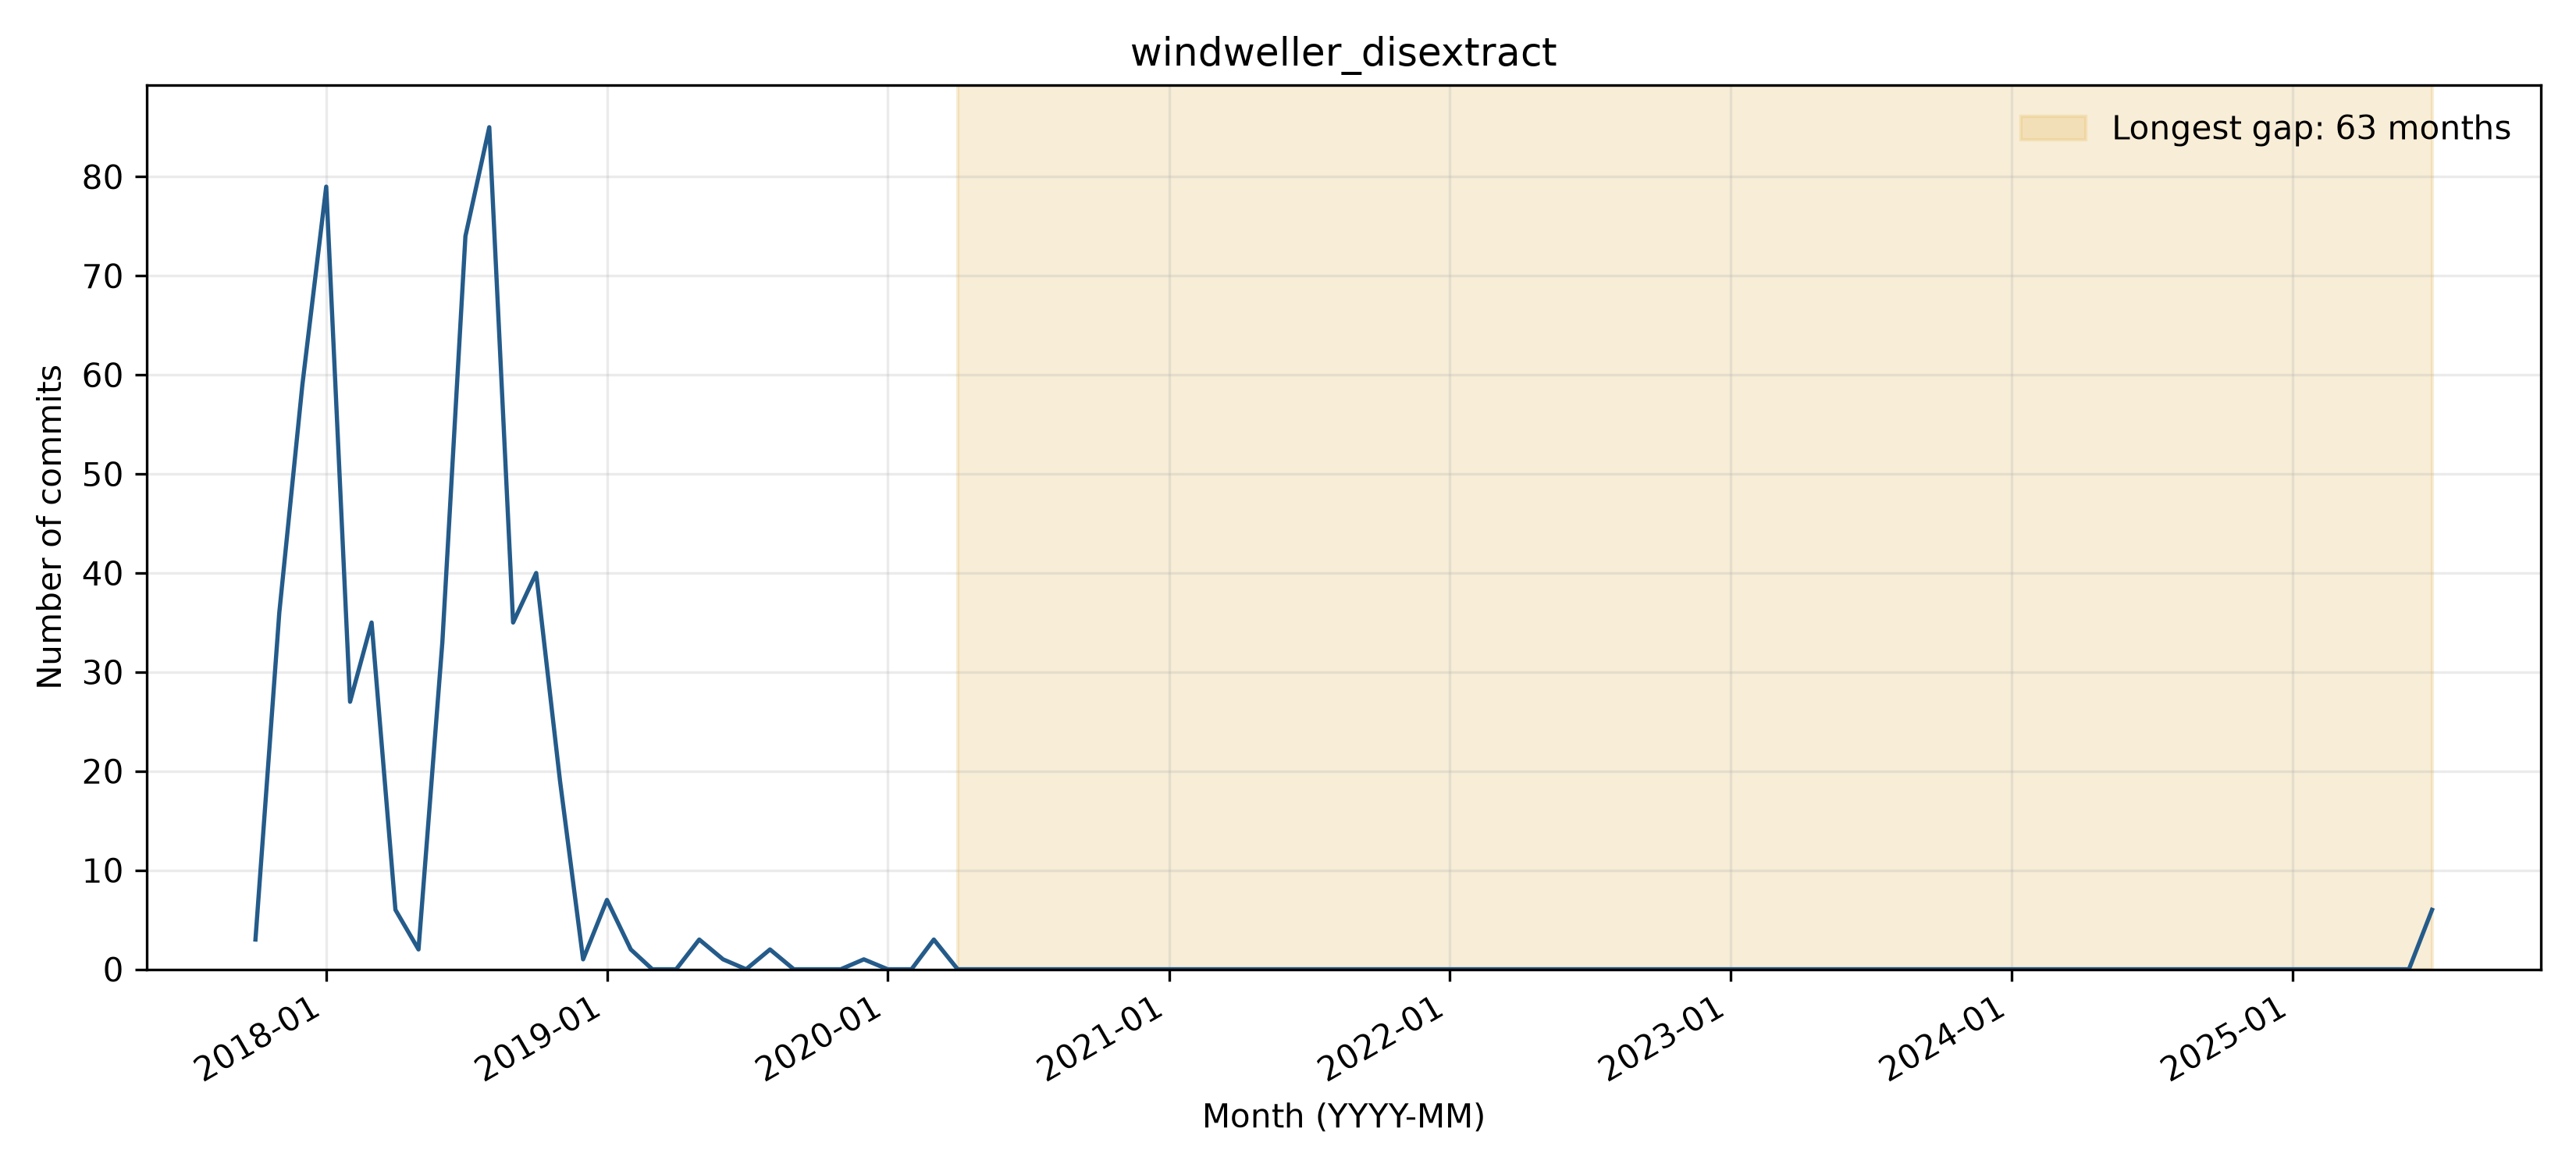

In [3]:
if ready:
    for project in stats['Project']:
        display(Image(filename=str(ROOT / f'{NETID}_timeseries_{project}.png'), width=900))

## Interpretation

7 of ten projects have complete WoC details. Only fully retrieved projects are plotted.

### avehtari_bda_course_aalto

Repeated late-summer/autumn bursts are consistent with the annual course cycle, although their magnitudes vary substantially. The longest gap is February-June 2025, with three gaps of at least three months overall. Automated site-deployment commits contribute heavily to the counts, so this measures repository activity rather than only human editing effort.

### eberharf_cfl

Activity rises to large monthly bursts in early 2021, then falls sharply. The December 2023 restart and scattered 2024-2025 commits remain far below that initial intensity, so the overall trajectory is declining. There are two gaps of at least three months.

### openda-association_openda

Awaiting complete WoC retrieval.

### openms_openms

Awaiting complete WoC retrieval.

### vatlab_sos

Complete quantitative data; interpretation pending.

### jayggg_ngstents

The strongest activity occurs in 2020 and early 2021, followed by lower activity and long pauses. Later bursts in 2023 and 2024 are smaller and isolated, so declining is a reasonable overall classification. Four zero-month runs last at least three months.

### inqwire_sqir

Large development bursts in 2019-2021 give way to much lower activity from 2022 onward. Small 2024-2025 bursts do not return to the earlier intensity, supporting a declining overall trajectory. Five gaps last at least three months.

### tee-lab_pyddsde

Activity is irregular, with 30 commits in September 2020, a two-month pause, and a larger burst of 59 commits in February 2021. There are zero inactivity gaps of at least three months. The isolated peaks do not establish a recurring seasonal cycle.

### jgcri_gcam-core

Awaiting complete WoC retrieval.

### windweller_disextract

Activity is concentrated in 2017-2018, dwindles to occasional documentation changes, and then stops for 63 months. The six WoC commits on a single July 2025 day represent only a brief return, not a sustained rising trajectory. Two gaps last at least three months.

## Gap evidence and reflections

Completed evidence-based reviews are in `bdowlin2_reflection_<WOCProjectID>.md`, with reviewed fields stored in `gap_reviews.json`. The final-format statistics CSV includes all ten projects and explicit `WoCDataComplete` and `GapReviewComplete` flags. Blank fields are unavailable, not zero.

The gap sample CSV includes only projects with fully retrieved histories. The per-commit theme labels are in `bdowlin2_gap_commit_themes.csv`; the recent GitHub themes are in `bdowlin2_recent_commit_themes.csv` and explained in `bdowlin2_recent_themes.md`. Source counts are compared in `bdowlin2_source_comparison.csv`.

For projects still awaiting review, read full boundary messages and check dated GitHub issues/PRs and README changes before recording causes. Compare the post-gap authors with the entire pre-gap history. Commit resumption does not prove sustained recovery, and a new author string does not by itself prove a new person.

In [4]:
if ready:
    samples = pd.read_csv(ROOT / f'{NETID}_project_gap_commits.csv', sep=';', keep_default_na=False)
    display(samples)
    print('Samples shown cover completed datasets. Check GapReviewComplete in bdowlin2_project_stats.csv for evidence-review status.')

,pre/post,project_wocid,commit_sha1,author,time,commit message
0,pre,avehtari_bda_course_aalto,7c88a18ab057716bb9bbfb7191f57b74acd6ebaa,Quarto GHA Workflow Runner <quarto-github-acti...,1732803947,Built site for gh-pages\n
1,pre,avehtari_bda_course_aalto,1c48cfdd5a5b212e4de259821d9d51d3b0b52fdb,Aki Vehtari <Aki.Vehtari@aalto.fi>,1732804403,updated instructions and minor fixes\n
2,pre,avehtari_bda_course_aalto,1b987c7089b5de9ecbad74a97eb8fe054aa3acec,Quarto GHA Workflow Runner <quarto-github-acti...,1732804672,Built site for gh-pages\n
3,pre,avehtari_bda_course_aalto,af8c45e10eed0511ffae84102f54a2bf98257c8a,davkoh <53530807+davkoh@users.noreply.github.com>,1733311087,Update of project feedback deadline
4,pre,avehtari_bda_course_aalto,629fa637a4c9cd631d50e89fa8d70adf95ab9903,Quarto GHA Workflow Runner <quarto-github-acti...,1733311370,Built site for gh-pages\n
...,...,...,...,...,...,...
111,post,windweller_disextract,4c3984ea3c0326d38d54f9ef8aa2292e2b2ad9ee,testtt7272 <testtt7272@gmail.com>,1752416950,Add files via upload
112,post,windweller_disextract,acee584fac9fd411f00d9534c56435cf176a50af,testtt7272 <testtt7272@gmail.com>,1752418089,Update bookcorpus.py
113,post,windweller_disextract,5f316e00ebf1cffbd42b8e0af1cb653d030983d4,testtt7272 <testtt7272@gmail.com>,1752418455,Update bookcorpus.py
114,post,windweller_disextract,d06b29318aab45e920295d2803cc7aadc922e5d8,windweller <testtt7272@gmail.com>,1752419432,Update bookcorpus.py


Samples shown cover completed datasets. Check GapReviewComplete in bdowlin2_project_stats.csv for evidence-review status.
